# Analyze SWE and Streamflow for Starvation Reservoir

This notebook analyzes SNOTEL SWE and USGS streamflow data for the Starvation Reservoir basin. The goal is to evaluate snowpack conditions on April 1, 2025 and provide reservoir management recommendations.

**SNOTEL Site:** Strawberry Divide (795:UT:SNTL)
**USGS Gauge:** 09285900 - Strawberry River at Pinnacles near Fruitland, UT

In [34]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

os.makedirs('figures', exist_ok=True)

# load data from the acquisition notebook
swe     = pd.read_csv('data/swe.csv',     parse_dates=['date'])
monthly = pd.read_csv('data/monthly.csv')
peak    = pd.read_csv('data/peak_swe.csv')

# add day of water year - DOWY 1 = Oct 1, DOWY 183 = Apr 1
swe['dowy'] = swe.apply(
    lambda r: (r['date'] - pd.Timestamp(f"{int(r['wy'])-1}-10-01")).days + 1, axis=1
)

print('data loaded')
swe.head()

data loaded


,date,swe_m,wy,dowy
0,1980-01-01,0.11684,1980,93
1,1980-01-02,0.11684,1980,94
2,1980-01-03,0.11684,1980,95
3,1980-01-04,0.12192,1980,96
4,1980-01-05,0.12192,1980,97


## SWE Analysis - Figure 1

Plot the historical range of SWE at Strawberry Divide compared to WY2025. The shaded bands show the 10th-90th and 25th-75th percentile of the historical record. WY2025 is shown in red and the vertical line marks April 1.

In [35]:
# split into historical (before WY2025) and WY2025
hist     = swe[swe['wy'] < 2025]
swe_2025 = swe[swe['wy'] == 2025]

# compute percentile statistics by day of water year
s = hist.groupby('dowy')['swe_m'].agg(
    median='median',
    p10=lambda x: np.percentile(x.dropna(), 10),
    p25=lambda x: np.percentile(x.dropna(), 25),
    p75=lambda x: np.percentile(x.dropna(), 75),
    p90=lambda x: np.percentile(x.dropna(), 90)
).reset_index()

# get April 1 values for comparison
apr1_2025 = swe[(swe['wy'] == 2025) & (swe['date'].dt.strftime('%m-%d') == '04-01')]['swe_m'].values
apr1_med  = s[s['dowy'] == 183]['median'].values
print(f'April 1, 2025 SWE: {apr1_2025[0]:.3f} m  |  Historical median: {apr1_med[0]:.3f} m')
print(f'WY2025 is {apr1_2025[0]/apr1_med[0]*100:.0f}% of the historical median')

April 1, 2025 SWE: 0.351 m  |  Historical median: 0.404 m
WY2025 is 87% of the historical median


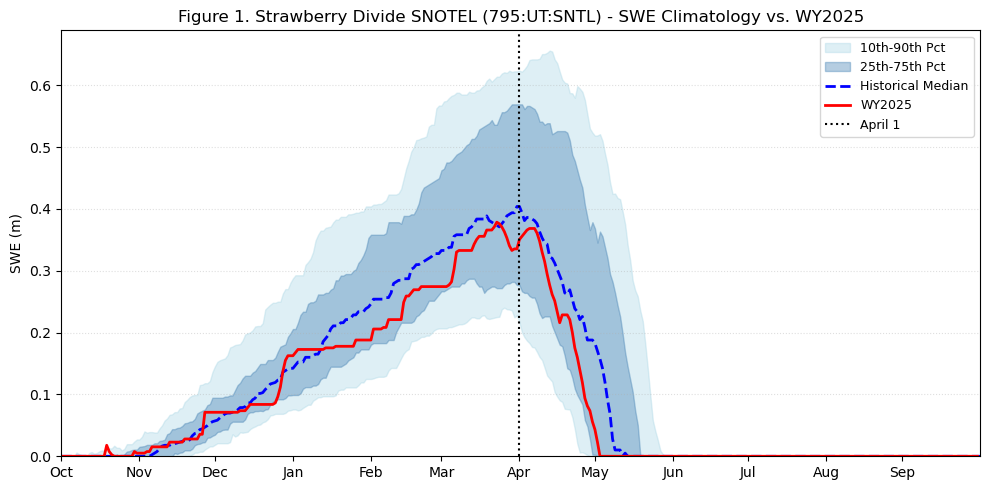

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))

# shaded percentile bands
ax.fill_between(s['dowy'], s['p10'], s['p90'], color='lightblue', alpha=0.4, label='10th-90th Pct')
ax.fill_between(s['dowy'], s['p25'], s['p75'], color='steelblue', alpha=0.4, label='25th-75th Pct')

# historical median and WY2025
ax.plot(s['dowy'], s['median'], 'b--', linewidth=2, label='Historical Median')
ax.plot(swe_2025['dowy'], swe_2025['swe_m'], 'r-', linewidth=2, label='WY2025')

# April 1 vertical line
ax.axvline(x=183, color='k', linestyle=':', linewidth=1.5, label='April 1')

# month labels on x axis
ax.set_xticks([1, 32, 62, 93, 124, 152, 183, 213, 244, 274, 305, 335])
ax.set_xticklabels(['Oct','Nov','Dec','Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep'])
ax.set_ylabel('SWE (m)')
ax.set_xlim(1, 366)
ax.set_ylim(bottom=0)
ax.set_title('Figure 1. Strawberry Divide SNOTEL (795:UT:SNTL) - SWE Climatology vs. WY2025', fontsize=12)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig('figures/fig1_swe_climatology.png', dpi=150)
plt.show()

## Monthly Streamflow Analysis - Figure 2

Plot the historical range of monthly streamflow volume for April through September. The red diamond marks the WY2025 value for each month.

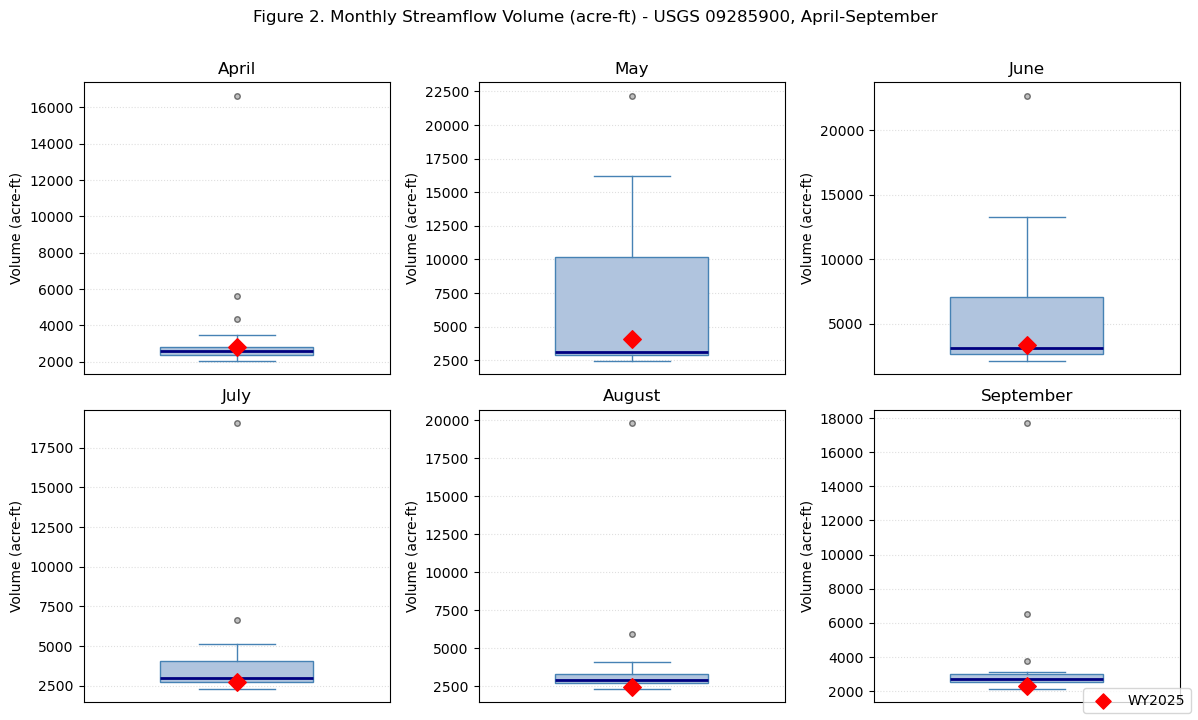

In [37]:
months      = [4, 5, 6, 7, 8, 9]
month_names = ['April', 'May', 'June', 'July', 'August', 'September']

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

for i, (mo, name) in enumerate(zip(months, month_names)):
    ax = axes[i]

    # historical data for this month
    hist     = monthly[(monthly['month'] == mo) & (monthly['wy'] < 2025)]['vol_acft'].dropna()
    val_2025 = monthly[(monthly['month'] == mo) & (monthly['wy'] == 2025)]['vol_acft'].values

    # box plot showing historical distribution
    ax.boxplot(hist, positions=[1], widths=0.5, patch_artist=True,
               boxprops=dict(facecolor='lightsteelblue', color='steelblue'),
               medianprops=dict(color='navy', linewidth=2),
               whiskerprops=dict(color='steelblue'),
               capprops=dict(color='steelblue'),
               flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.5))

    # WY2025 as a red diamond
    if len(val_2025) > 0:
        ax.scatter(1, val_2025[0], color='red', zorder=5, s=80, marker='D')

    ax.set_title(name)
    ax.set_ylabel('Volume (acre-ft)')
    ax.set_xticks([])
    ax.grid(axis='y', linestyle=':', alpha=0.4)

fig.legend(handles=[plt.scatter([], [], color='red', marker='D', s=60, label='WY2025')],
           loc='lower right')
fig.suptitle('Figure 2. Monthly Streamflow Volume (acre-ft) - USGS 09285900, April-September',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('figures/fig2_monthly_flow.png', dpi=150, bbox_inches='tight')
plt.show()

## Peak SWE vs Monthly Streamflow - Figure 3

Compare annual peak SWE at Strawberry Divide to monthly streamflow volume for April through September. A linear regression line and R² value are shown for each month. WY2025 is shown in red.

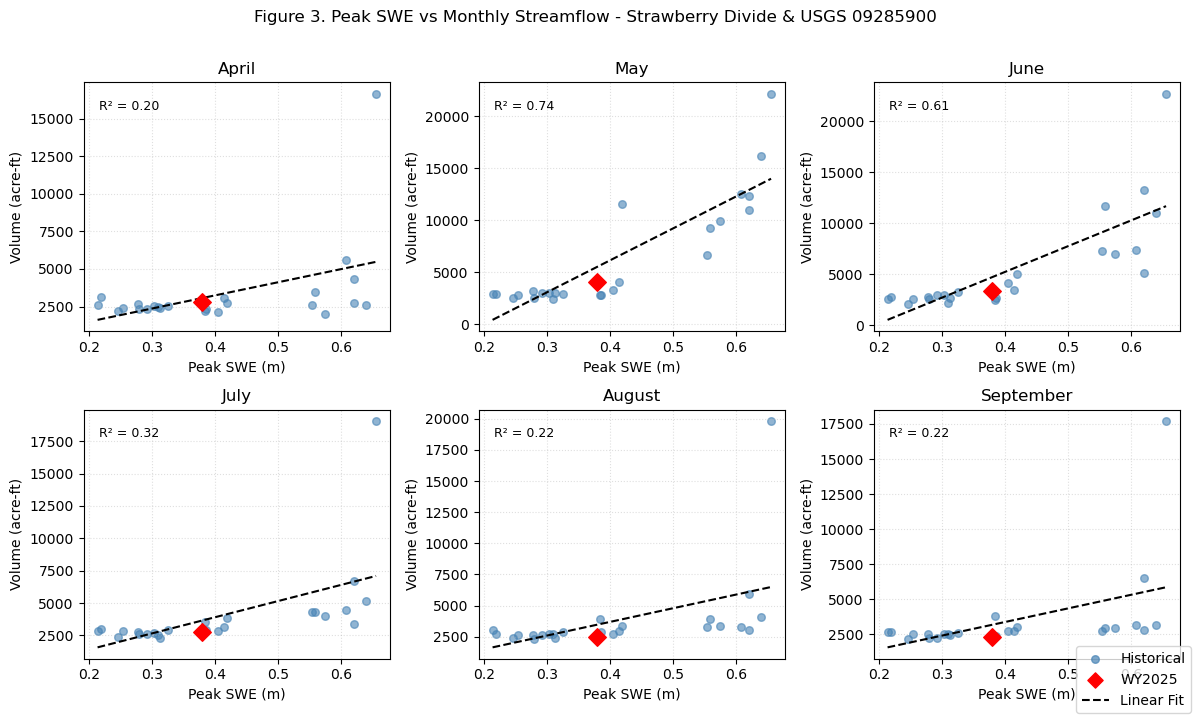

In [38]:
# merge peak SWE with monthly flow on water year
df = peak.merge(monthly, on='wy')

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

for i, (mo, name) in enumerate(zip(months, month_names)):
    ax = axes[i]

    # split into historical and WY2025
    hist = df[(df['month'] == mo) & (df['wy'] < 2025)].dropna(subset=['peak_swe_m', 'vol_acft'])
    d25  = df[(df['month'] == mo) & (df['wy'] == 2025)]

    x = hist['peak_swe_m'].values
    y = hist['vol_acft'].values

    # scatter plot of historical years
    ax.scatter(x, y, color='steelblue', alpha=0.6, s=30, label='Historical')

    # linear regression
    if len(x) > 2:
        slope, intercept, r, _, _ = stats.linregress(x, y)
        x_fit = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_fit, slope * x_fit + intercept, 'k--', linewidth=1.5)
        ax.text(0.05, 0.93, f'R² = {r**2:.2f}', transform=ax.transAxes, fontsize=9, va='top')

    # WY2025 point
    if len(d25) > 0:
        ax.scatter(d25['peak_swe_m'], d25['vol_acft'], color='red', s=80, marker='D', zorder=5, label='WY2025')

    ax.set_title(name)
    ax.set_xlabel('Peak SWE (m)')
    ax.set_ylabel('Volume (acre-ft)')
    ax.grid(linestyle=':', alpha=0.4)

handles = [
    plt.scatter([], [], color='steelblue', s=30, alpha=0.7, label='Historical'),
    plt.scatter([], [], color='red', marker='D', s=60, label='WY2025'),
    plt.Line2D([0], [0], color='black', linestyle='--', linewidth=1.5, label='Linear Fit')
]
fig.legend(handles=handles, loc='lower right')
fig.suptitle('Figure 3. Peak SWE vs Monthly Streamflow - Strawberry Divide & USGS 09285900',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('figures/fig3_peak_swe_vs_flow.png', dpi=150, bbox_inches='tight')
plt.show()